Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
                                            low_path  \
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.941111  
3  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.954074  
4  c:\Users\Ghozy Abror\OneDrive - Institut Tekn

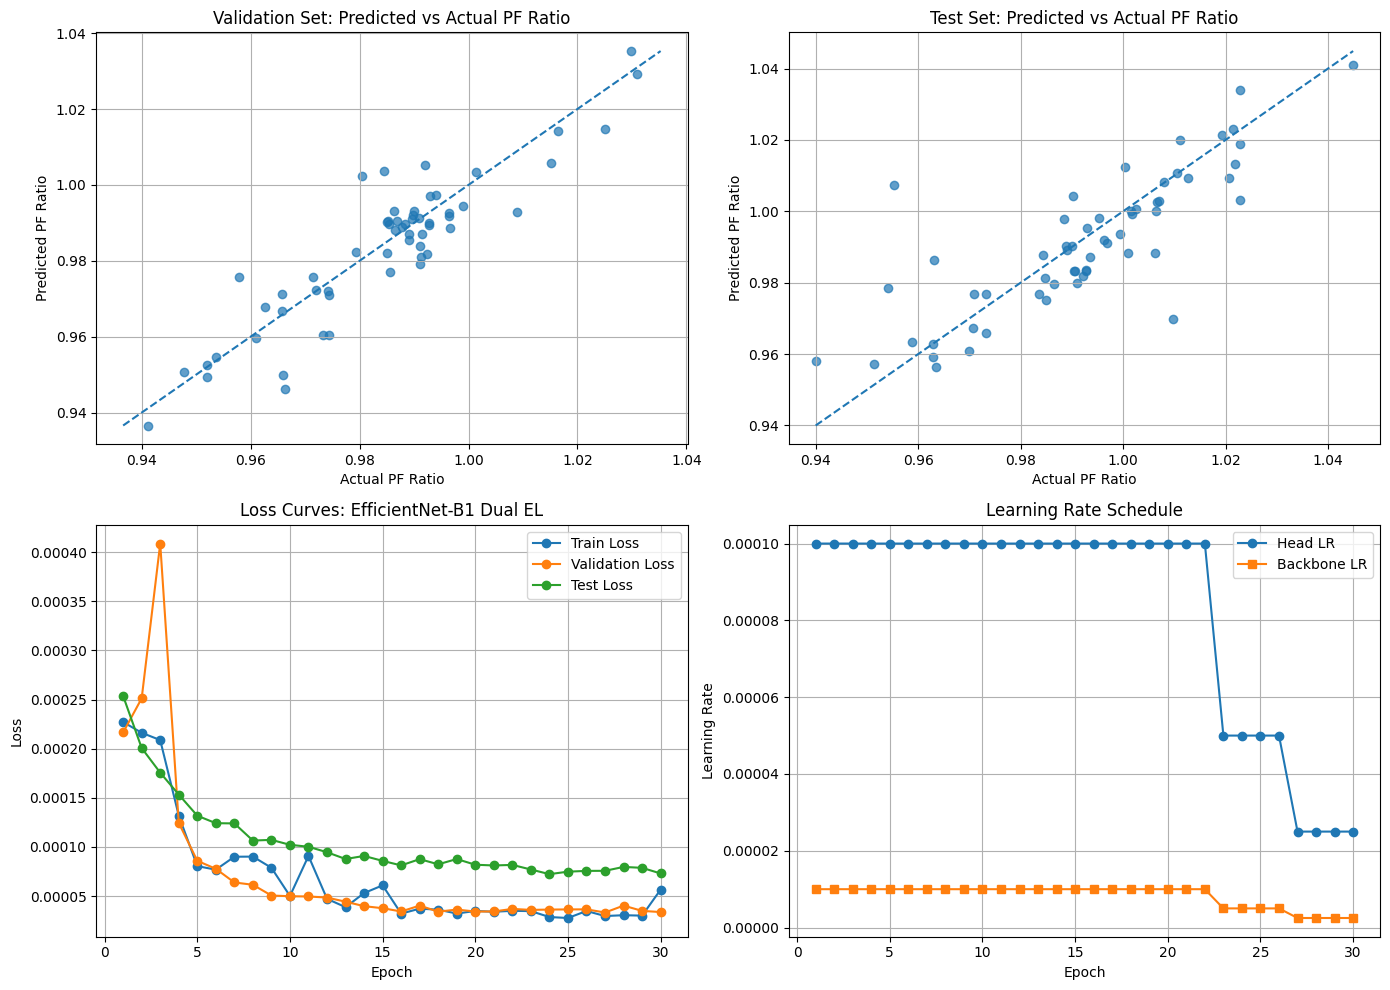


Saved:
- results_effnet_b1_dual_el_pf_ratio.png
- validation_predictions_effnet_b1_dual_el.csv
- test_predictions_effnet_b1_dual_el.csv
- effnet_b1_dual_el_pf_ratio_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB.csv"

# EfficientNet-B1 recommended crop/input size
IMAGE_SIZE = 240

# For RTX 3050 4GB, start with 16.
# If CUDA out of memory, change to 8.
BATCH_SIZE = 16

NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """
    Convert relative paths from CSV into absolute paths.

    If add_wrp=True:
    xxx.tiff -> xxx_wrp.tiff
    """
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()

    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load CSV, compute PF ratio, resolve low/high EL paths,
    and keep only valid rows.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = ["ELLPath", "ELHPath", "Pmp_(W)", "Nameplate_Pmp_(W)"]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(df["Nameplate_Pmp_(W)"], errors="coerce")

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["low_path"] = df["ELLPath"].apply(lambda p: resolve_relative_path(p, base_dir))
    df["high_path"] = df["ELHPath"].apply(lambda p: resolve_relative_path(p, base_dir))

    df = df[df["low_path"].notna() & df["high_path"].notna()].copy()

    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    optional_id_cols = [
        c for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + ["low_path", "high_path", "pf_ratio"]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=240):
    """
    Resize grayscale image while preserving aspect ratio,
    then pad to square target_size x target_size.

    This avoids stretching the PV module shape.
    """
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        img,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2

    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        """
        Read and resize every low/high image once, then store as uint8 in RAM.
        """
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} images) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_low = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        self.cache_high = np.empty(
            (n, self.image_size, self.image_size),
            dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                low_img = read_grayscale_tiff(row["low_path"])
                high_img = read_grayscale_tiff(row["high_path"])

                self.cache_low[i] = resize_with_padding_gray(
                    low_img,
                    self.image_size
                )

                self.cache_high[i] = resize_with_padding_gray(
                    high_img,
                    self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, low_img, high_img):
        """
        Apply the same flip augmentation to low/high image pair.
        """
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = read_grayscale_tiff(row["low_path"])
            high_img = read_grayscale_tiff(row["high_path"])

            low_img = resize_with_padding_gray(low_img, self.image_size)
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # Shape: [2, H, W]
        x = np.concatenate([low_img, high_img], axis=0)

        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32)
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """
    EfficientNet-B1 modified to accept 2-channel input:
    channel 0 = low-bias EL
    channel 1 = high-bias EL

    Output: 1 bounded regression value, PF ratio.
    """
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    # EfficientNet first conv:
    # model.features[0][0] = Conv2d(3, ..., ...)
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False
    )

    with torch.no_grad():
        if pretrained:
            # Convert pretrained RGB conv into grayscale-like filters,
            # then apply to low/high channels.
            rgb_mean = old_conv.weight.mean(dim=1)

            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean

            # Keep activation scale roughly similar after changing 3ch -> 2ch
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight,
                mode="fan_out",
                nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    # EfficientNet classifier:
    # classifier[0] = Dropout
    # classifier[1] = Linear(...)
    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features,
        min_val=0.80,
        max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device)
        targets = targets.to(device).unsqueeze(1)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device)
            targets = targets.to(device).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.array(preds)
    trues = np.array(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds)

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING
# =========================================================
def plot_scatter(ax, trues, preds, title):
    ax.scatter(trues, preds, alpha=0.7)

    min_val = min(trues.min(), preds.min())
    max_val = max(trues.max(), preds.max())

    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError(
            "Too few valid samples remain after filtering for 0.8/0.1/0.1 split."
        )

    print("\nSample rows:")
    print(df.head())

    train_df, temp_df = train_test_split(
        df,
        test_size=0.2,
        random_state=RANDOM_SEED
    )

    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.5,
        random_state=RANDOM_SEED
    )

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = DualELDataset(
        train_df,
        image_size=IMAGE_SIZE,
        augment=True,
        preload=PRELOAD_TO_RAM
    )

    val_dataset = DualELDataset(
        val_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    test_dataset = DualELDataset(
        test_df,
        image_size=IMAGE_SIZE,
        augment=False,
        preload=PRELOAD_TO_RAM
    )

    pin_memory = True if DEVICE.type == "cuda" else False

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")

    train_losses = []
    val_losses = []
    test_losses = []

    train_maes = []
    val_maes = []
    test_maes = []

    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 70}")
    print("Starting training: EfficientNet-B1, dual low/high EL, unfrozen backbone")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 70}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            DEVICE
        )

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model,
            train_loader,
            criterion,
            DEVICE
        )

        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model,
            val_loader,
            criterion,
            DEVICE
        )

        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model,
            test_loader,
            criterion,
            DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        train_maes.append(train_mae)
        val_maes.append(val_mae)
        test_maes.append(test_mae)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0

    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model,
        test_loader,
        criterion,
        DEVICE
    )

    print("\nBest Model Performance selected by Validation RMSE")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    plot_scatter(
        axes[0, 0],
        val_trues,
        val_preds,
        "Validation Set: Predicted vs Actual PF Ratio"
    )

    plot_scatter(
        axes[0, 1],
        test_trues,
        test_preds,
        "Test Set: Predicted vs Actual PF Ratio"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        train_losses,
        label="Train Loss",
        marker="o"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        val_losses,
        label="Validation Loss",
        marker="o"
    )

    axes[1, 0].plot(
        range(1, NUM_EPOCHS + 1),
        test_losses,
        label="Test Loss",
        marker="o"
    )

    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Loss")
    axes[1, 0].set_title("Loss Curves: EfficientNet-B1 Dual EL")
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        head_lrs,
        marker="o",
        label="Head LR"
    )

    axes[1, 1].plot(
        range(1, NUM_EPOCHS + 1),
        backbone_lrs,
        marker="s",
        label="Backbone LR"
    )

    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Learning Rate")
    axes[1, 1].set_title("Learning Rate Schedule")
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    plt.tight_layout()

    result_fig_path = "results_effnet_b1_dual_el_pf_ratio.png"

    plt.savefig(
        result_fig_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    val_results_df = pd.DataFrame(
        {
            "actual_pf_ratio": val_trues,
            "predicted_pf_ratio": val_preds
        }
    )

    val_csv_path = "validation_predictions_effnet_b1_dual_el.csv"
    val_results_df.to_csv(val_csv_path, index=False)

    test_results_df = pd.DataFrame(
        {
            "actual_pf_ratio": test_trues,
            "predicted_pf_ratio": test_preds
        }
    )

    test_csv_path = "test_predictions_effnet_b1_dual_el.csv"
    test_results_df.to_csv(test_csv_path, index=False)

    save_path = "effnet_b1_dual_el_pf_ratio_best_val_model.pth"
    torch.save(model.state_dict(), save_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {save_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")

Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
   Make make_plot  split                                           low_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Insti

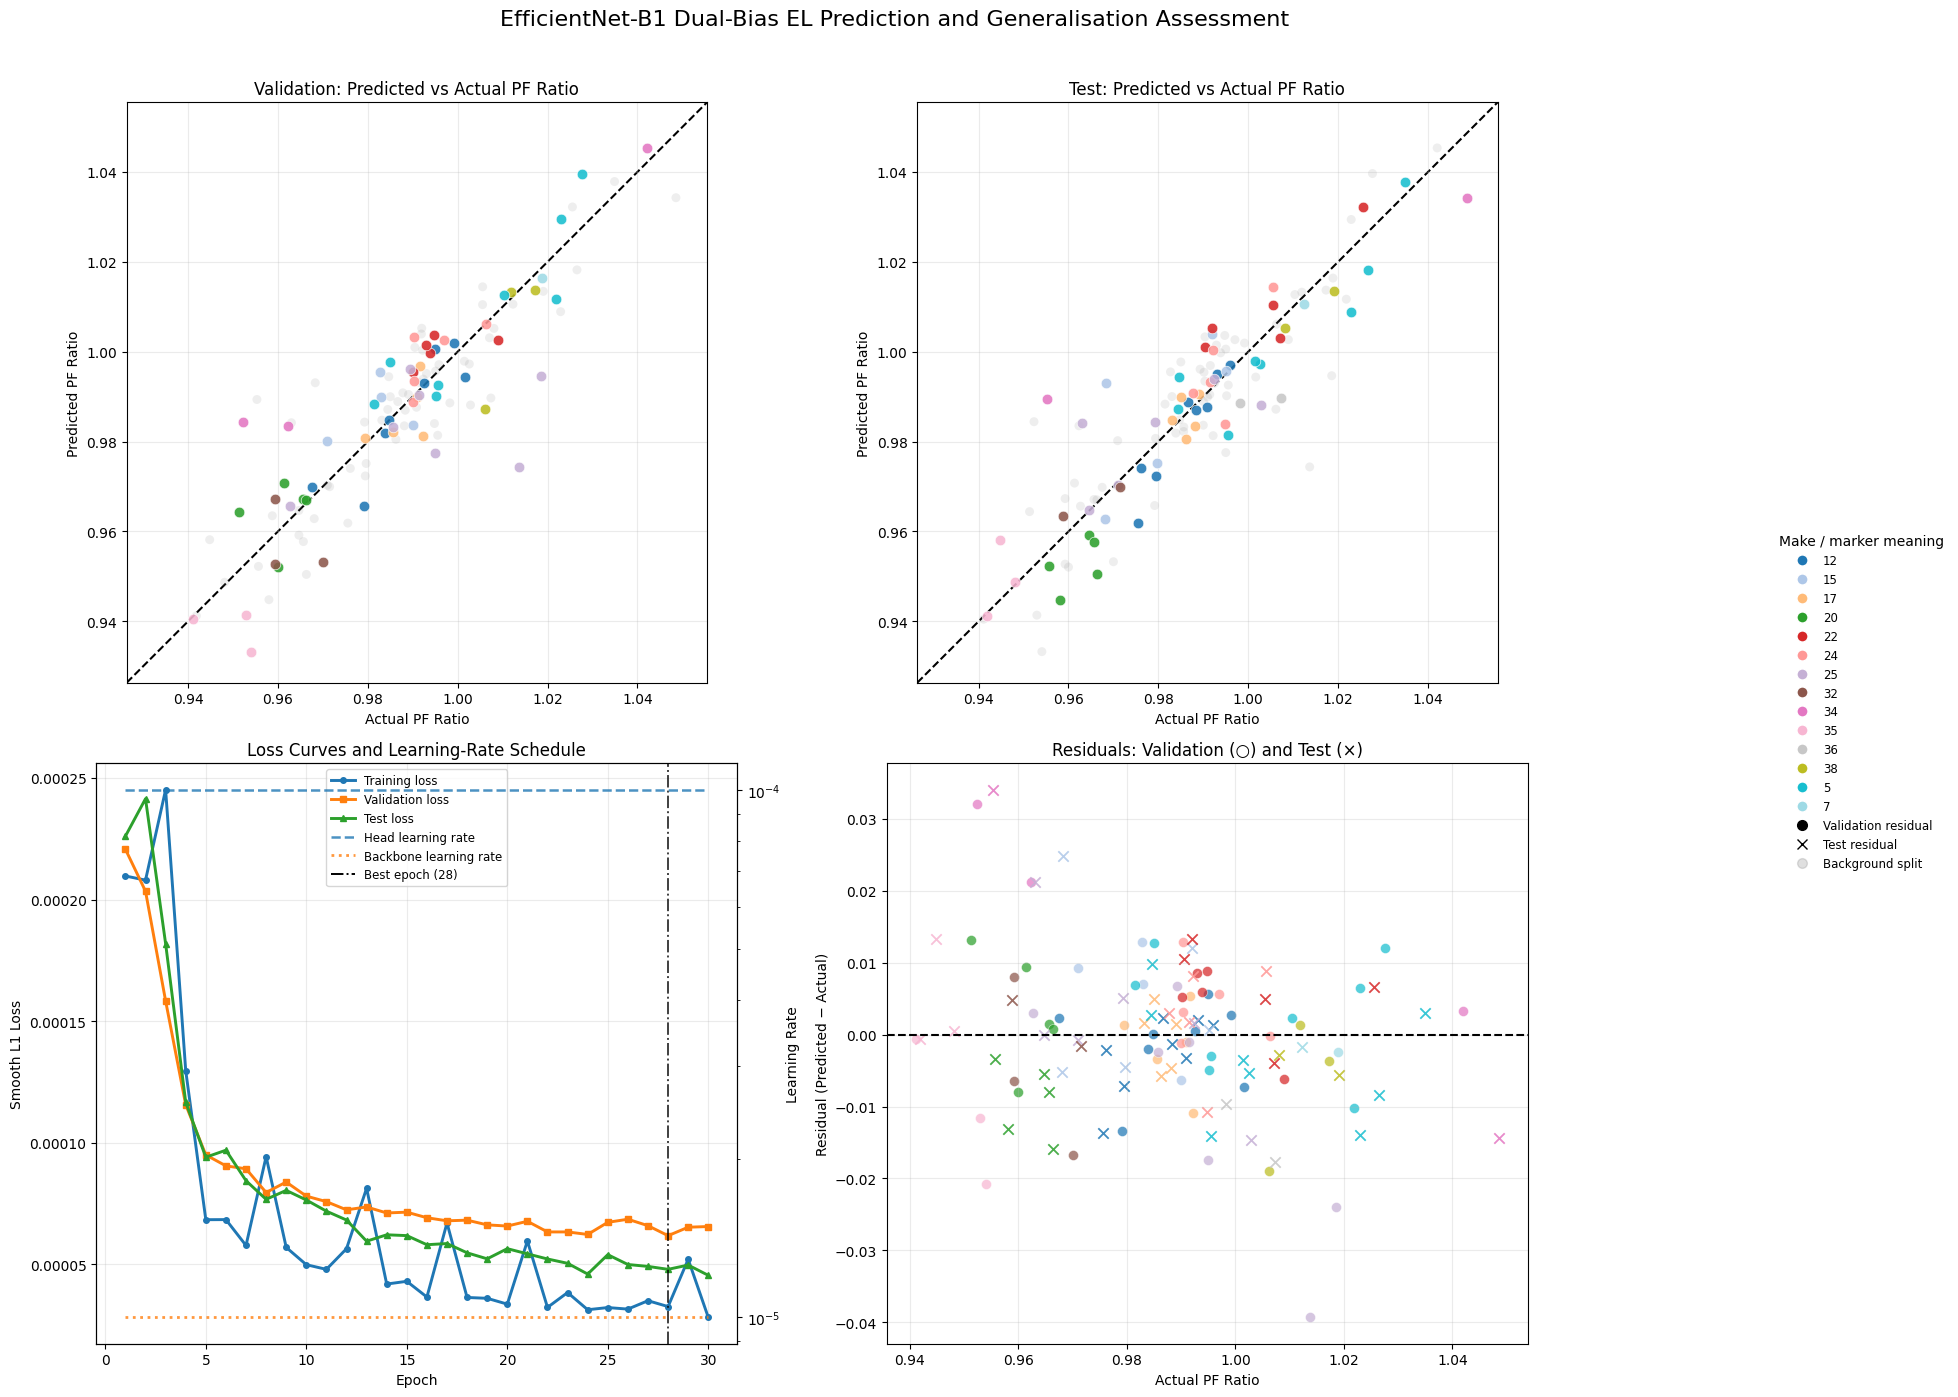


Saved:
- results_effnet_b1_dual_fixedsplit_generalization.png
- validation_predictions_effnet_b1_dual_fixedsplit.csv
- test_predictions_effnet_b1_dual_fixedsplit.csv
- metrics_per_make_effnet_b1_dual_fixedsplit.csv
- training_history_effnet_b1_dual_fixedsplit.csv
- effnet_b1_dual_fixedsplit_best_val_model.pth
Cleanup done.


In [4]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

IMAGE_SIZE = 240
BATCH_SIZE = 16  # reduce to 8 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, resolve image paths,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELLPath",
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["low_path"] = df["ELLPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )
    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )

    df = df[df["low_path"].notna() & df["high_path"].notna()].copy()

    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = (
        df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    )

    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "low_path",
        "high_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=240):
    """Preserve image aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=240, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} images) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_low = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )
        self.cache_high = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                low_img = read_grayscale_tiff(row["low_path"])
                high_img = read_grayscale_tiff(row["high_path"])

                self.cache_low[i] = resize_with_padding_gray(
                    low_img, self.image_size
                )
                self.cache_high[i] = resize_with_padding_gray(
                    high_img, self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, low_img, high_img):
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = read_grayscale_tiff(row["low_path"])
            high_img = read_grayscale_tiff(row["high_path"])

            low_img = resize_with_padding_gray(low_img, self.image_size)
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # Channel 0 = low-bias EL; channel 1 = high-bias EL
        x = np.concatenate([low_img, high_img], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b1_2ch(pretrained=True):
    """EfficientNet-B1 modified for dual low/high-bias grayscale input."""
    weights = models.EfficientNet_B1_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b1(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="best",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = DualELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = DualELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = DualELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b1_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B1, dual EL, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B1 Dual-Bias EL Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b1_dual_fixedsplit_generalization.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b1_dual_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b1_dual_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b1_dual_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b1_dual_fixedsplit.csv"
    model_path = "effnet_b1_dual_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


In [5]:
import gc
import torch

# Hapus object besar kalau masih ada
for name in [
    "train_ds", "val_ds", "test_ds",
    "train_ld", "val_ld", "test_ld",
    "model", "optimizer", "scheduler",
    "best_wts"
]:
    if name in globals():
        del globals()[name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

print("RAM/GPU cleanup done.")

RAM/GPU cleanup done.


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
   Make make_plot  split                                           low_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Insti

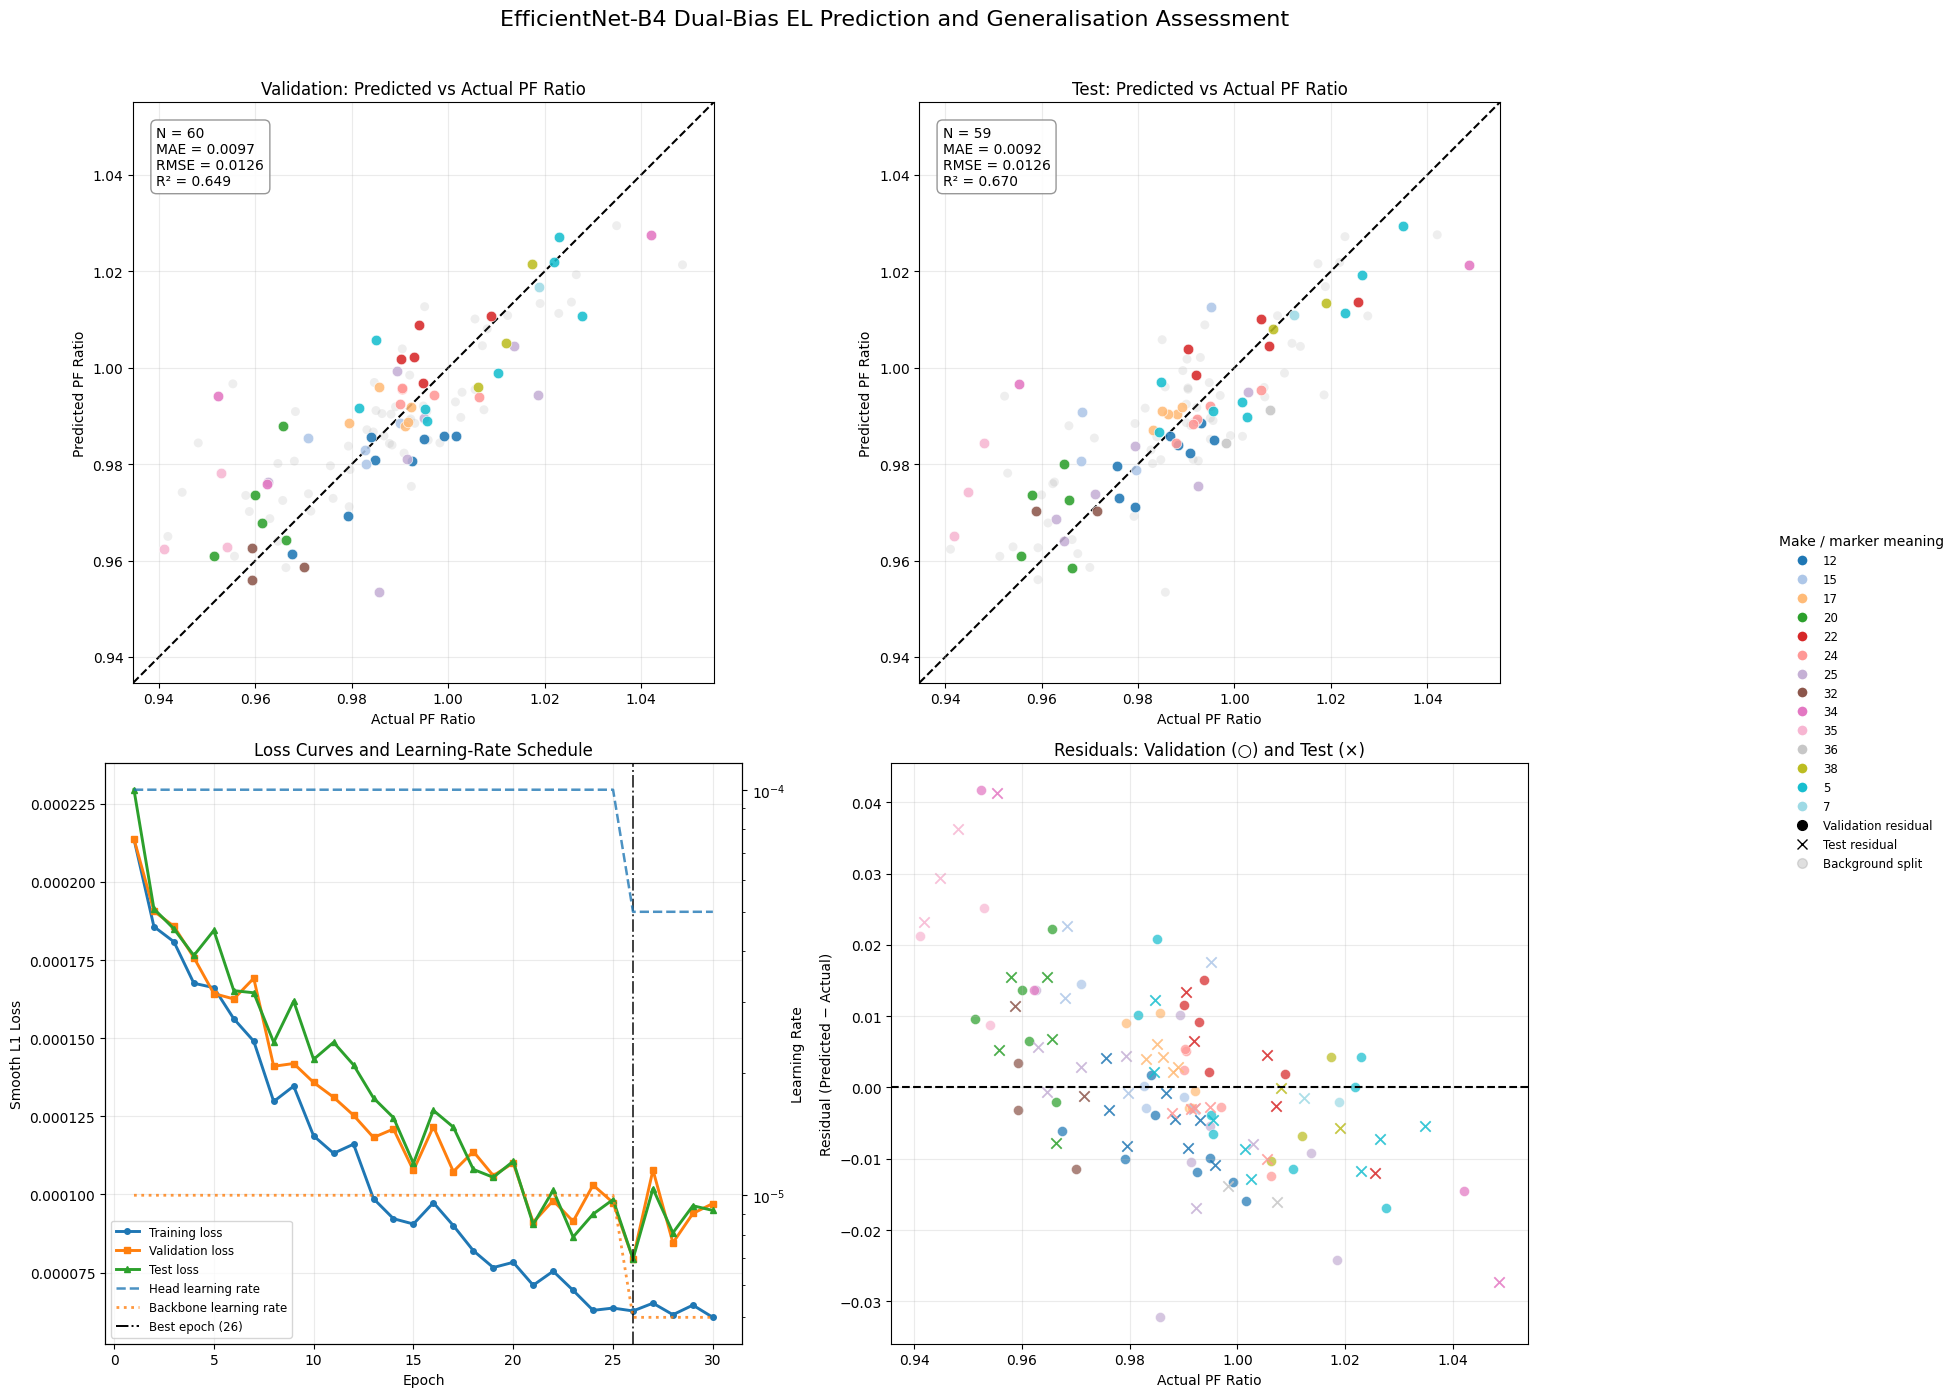


Saved:
- results_effnet_b4_dual_fixedsplit_generalization_metrics.png
- validation_predictions_effnet_b4_dual_fixedsplit.csv
- test_predictions_effnet_b4_dual_fixedsplit.csv
- metrics_per_make_effnet_b4_dual_fixedsplit.csv
- training_history_effnet_b4_dual_fixedsplit.csv
- effnet_b4_dual_fixedsplit_best_val_model.pth
Cleanup done.


In [1]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

IMAGE_SIZE = 380
BATCH_SIZE = 4  # dual-input B4 is heavy on a 4 GB RTX 3050; try 8 only if it fits
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, resolve image paths,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELLPath",
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["low_path"] = df["ELLPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )
    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )

    df = df[df["low_path"].notna() & df["high_path"].notna()].copy()

    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = (
        df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    )

    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "low_path",
        "high_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=380):
    """Preserve image aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=380, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} images) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_low = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )
        self.cache_high = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                low_img = read_grayscale_tiff(row["low_path"])
                high_img = read_grayscale_tiff(row["high_path"])

                self.cache_low[i] = resize_with_padding_gray(
                    low_img, self.image_size
                )
                self.cache_high[i] = resize_with_padding_gray(
                    high_img, self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, low_img, high_img):
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = read_grayscale_tiff(row["low_path"])
            high_img = read_grayscale_tiff(row["high_path"])

            low_img = resize_with_padding_gray(low_img, self.image_size)
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # Channel 0 = low-bias EL; channel 1 = high-bias EL
        x = np.concatenate([low_img, high_img], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_efficientnet_b4_2ch(pretrained=True):
    """EfficientNet-B4 modified for dual low/high-bias grayscale input."""
    weights = models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
    model = models.efficientnet_b4(weights=weights)

    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        bias=False,
    )

    with torch.no_grad():
        if pretrained:
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )

    model.features[0][0] = new_conv

    in_features = model.classifier[1].in_features
    model.classifier[1] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
    mae,
    rmse,
    r2,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Display overall regression metrics for the highlighted split.
    metrics_text = (
        f"N = {len(focus_df)}\n"
        f"MAE = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"R² = {r2:.3f}"
    )
    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "0.55",
            "alpha": 0.90,
        },
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="best",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = DualELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = DualELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = DualELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_efficientnet_b4_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: EfficientNet-B4, dual EL, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
        mae=val_mae,
        rmse=val_rmse,
        r2=val_r2,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
        mae=test_mae,
        rmse=test_rmse,
        r2=test_r2,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "EfficientNet-B4 Dual-Bias EL Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_effnet_b4_dual_fixedsplit_generalization_metrics.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_effnet_b4_dual_fixedsplit.csv"
    test_csv_path = "test_predictions_effnet_b4_dual_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_effnet_b4_dual_fixedsplit.csv"
    history_csv_path = "training_history_effnet_b4_dual_fixedsplit.csv"
    model_path = "effnet_b4_dual_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")


Using device: cuda
Torch version: 2.7.1+cu118
CUDA available: True
CUDA used by PyTorch: 11.8
GPU name: NVIDIA GeForce RTX 3050 Laptop GPU
Rows with valid power data before file filtering: 582
Rows with both EL files existing: 576
Rows removed due to missing image file(s): 6

Sample rows:
   Make make_plot  split                                           low_path  \
0    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
1    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
2    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
3    35        35    val  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   
4    35        35  train  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...   

                                           high_path  pf_ratio  
0  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.952963  
1  c:\Users\Ghozy Abror\OneDrive - Institut Tekno...  0.948889  
2  c:\Users\Ghozy Abror\OneDrive - Insti

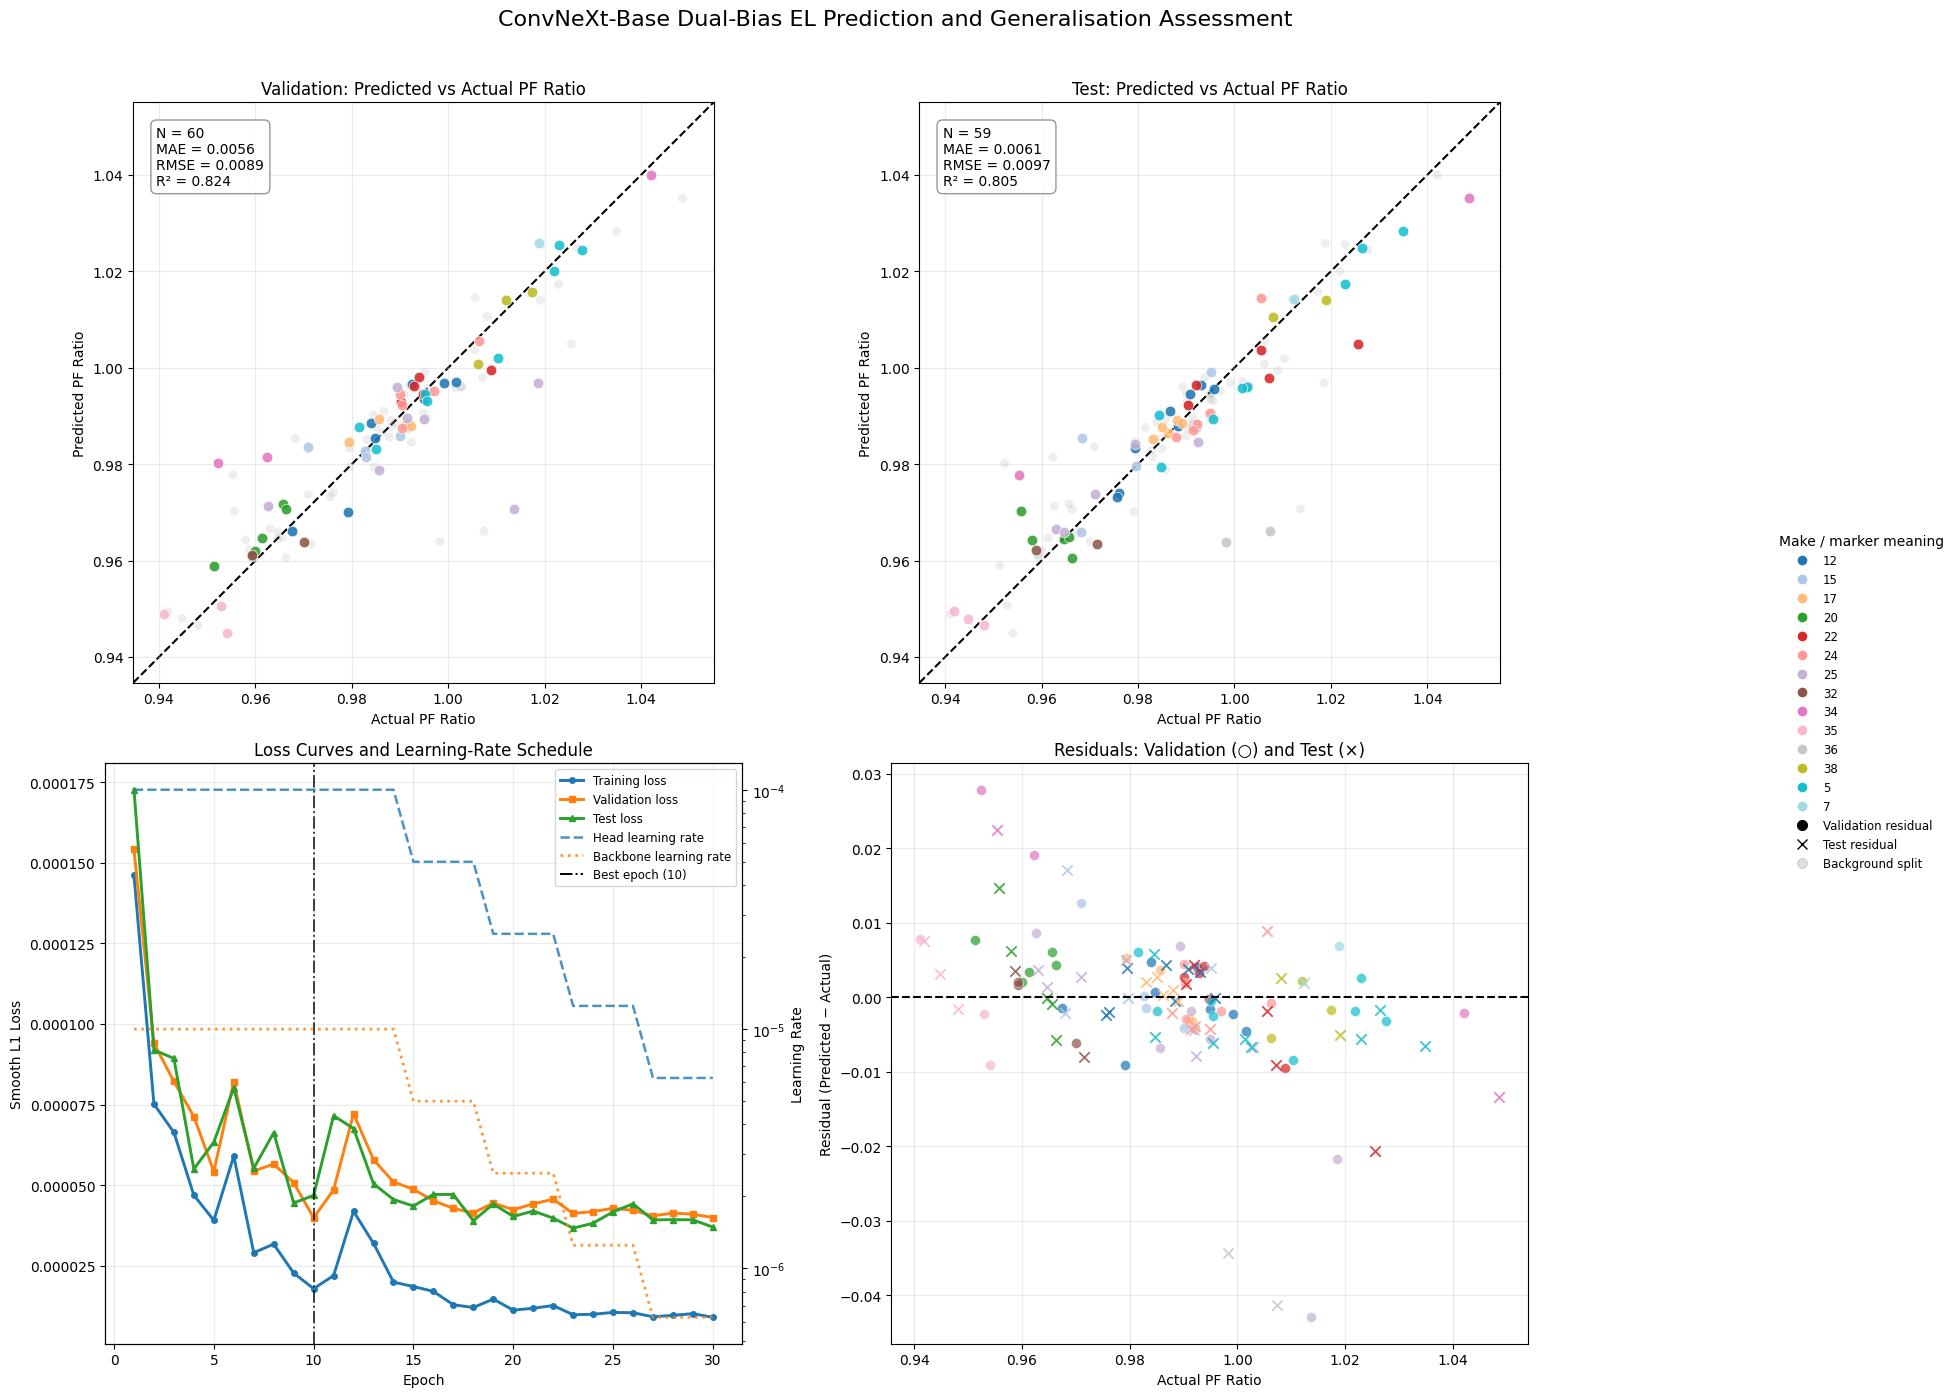


Saved:
- results_convnext_base_dual_fixedsplit_generalization_metrics.png
- validation_predictions_convnext_base_dual_fixedsplit.csv
- test_predictions_convnext_base_dual_fixedsplit.csv
- metrics_per_make_convnext_base_dual_fixedsplit.csv
- training_history_convnext_base_dual_fixedsplit.csv
- convnext_base_dual_fixedsplit_best_val_model.pth
Cleanup done.


In [2]:
import os
import math
import copy
import random
import time
import gc

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models


# =========================================================
# CONFIG
# =========================================================
CSV_PATH = "AnonDB_80_10_10_seed42.csv"
MAKE_COLUMN = "Make"
SPLIT_COLUMN = "split"

IMAGE_SIZE = 224
BATCH_SIZE = 2  # ConvNeXt-Base is heavy on a 4 GB RTX 3050; use 1 if CUDA runs out of memory
NUM_EPOCHS = 30
LEARNING_RATE = 1e-4
BACKBONE_LR = 1e-5
RANDOM_SEED = 42
NUM_WORKERS = 0
PRELOAD_TO_RAM = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA used by PyTorch:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


# =========================================================
# REPRODUCIBILITY
# =========================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_seed(RANDOM_SEED)


# =========================================================
# HELPER FUNCTIONS
# =========================================================
def resolve_relative_path(path_str, base_dir, add_wrp=True):
    """Resolve paths from the CSV relative to the CSV directory."""
    if pd.isna(path_str):
        return None

    path_str = str(path_str).strip()
    if path_str == "":
        return None

    path_str = path_str.replace("\\", os.sep).replace("/", os.sep)

    if add_wrp:
        root, ext = os.path.splitext(path_str)
        if not root.endswith("_wrp"):
            path_str = root + "_wrp" + ext

    if os.path.isabs(path_str):
        return os.path.normpath(path_str)

    if path_str.startswith("." + os.sep):
        path_str = path_str[2:]

    return os.path.normpath(os.path.join(base_dir, path_str))


def prepare_dataframe(csv_path):
    """
    Load the fixed-split CSV, compute PF ratio, resolve image paths,
    and retain Make and split information for plotting.
    """
    base_dir = os.path.dirname(os.path.abspath(csv_path))
    df = pd.read_csv(csv_path)

    required_cols = [
        "ELLPath",
        "ELHPath",
        "Pmp_(W)",
        "Nameplate_Pmp_(W)",
        MAKE_COLUMN,
        SPLIT_COLUMN,
    ]

    for col in required_cols:
        if col not in df.columns:
            raise ValueError(f"Missing required column in CSV: {col}")

    df["Pmp_(W)"] = pd.to_numeric(df["Pmp_(W)"], errors="coerce")
    df["Nameplate_Pmp_(W)"] = pd.to_numeric(
        df["Nameplate_Pmp_(W)"], errors="coerce"
    )

    df = df[
        df["Nameplate_Pmp_(W)"].notna()
        & (df["Nameplate_Pmp_(W)"] > 0)
        & df["Pmp_(W)"].notna()
    ].copy()

    df["pf_ratio"] = df["Pmp_(W)"] / df["Nameplate_Pmp_(W)"]

    df["low_path"] = df["ELLPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )
    df["high_path"] = df["ELHPath"].apply(
        lambda p: resolve_relative_path(p, base_dir)
    )

    df = df[df["low_path"].notna() & df["high_path"].notna()].copy()

    df["low_exists"] = df["low_path"].apply(os.path.exists)
    df["high_exists"] = df["high_path"].apply(os.path.exists)

    total_before = len(df)
    df = df[df["low_exists"] & df["high_exists"]].copy()
    total_after = len(df)

    print(f"Rows with valid power data before file filtering: {total_before}")
    print(f"Rows with both EL files existing: {total_after}")
    print(f"Rows removed due to missing image file(s): {total_before - total_after}")

    df[SPLIT_COLUMN] = (
        df[SPLIT_COLUMN].astype(str).str.strip().str.lower()
    )

    valid_split_names = {"train", "val", "test"}
    unknown_splits = set(df[SPLIT_COLUMN].unique()) - valid_split_names
    if unknown_splits:
        raise ValueError(
            "Unknown values in split column: " + ", ".join(sorted(unknown_splits))
        )

    df["make_plot"] = df[MAKE_COLUMN].fillna("Unknown").astype(str)

    optional_id_cols = [
        c
        for c in ["ID", "ModuleID", "Module", "Serial", "PanelID"]
        if c in df.columns
    ]

    keep_cols = optional_id_cols + [
        MAKE_COLUMN,
        "make_plot",
        SPLIT_COLUMN,
        "low_path",
        "high_path",
        "pf_ratio",
    ]

    return df[keep_cols].reset_index(drop=True)


# =========================================================
# IMAGE PROCESSING
# =========================================================
def read_grayscale_tiff(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Failed to load image: {path}")

    return img


def resize_with_padding_gray(img, target_size=224):
    """Preserve image aspect ratio and pad to a square input."""
    h, w = img.shape[:2]

    scale = target_size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))

    interpolation = cv2.INTER_AREA if scale < 1 else cv2.INTER_LINEAR
    resized = cv2.resize(img, (new_w, new_h), interpolation=interpolation)

    canvas = np.zeros((target_size, target_size), dtype=np.uint8)

    y0 = (target_size - new_h) // 2
    x0 = (target_size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized

    return canvas


# =========================================================
# DATASET
# =========================================================
class DualELDataset(Dataset):
    def __init__(self, dataframe, image_size=224, augment=False, preload=False):
        self.df = dataframe.reset_index(drop=True)
        self.image_size = image_size
        self.augment = augment
        self.cache = False

        if preload:
            self._preload_all()

    def _preload_all(self):
        n = len(self.df)
        expected_mb = n * 2 * self.image_size * self.image_size / (1024 ** 2)

        print(f"\nPreloading {n} samples ({n * 2} images) into RAM...")
        print(f"Expected memory: ~{expected_mb:.0f} MB")

        t0 = time.time()

        self.cache_low = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )
        self.cache_high = np.empty(
            (n, self.image_size, self.image_size), dtype=np.uint8
        )

        failed = 0

        for i in range(n):
            row = self.df.iloc[i]

            try:
                low_img = read_grayscale_tiff(row["low_path"])
                high_img = read_grayscale_tiff(row["high_path"])

                self.cache_low[i] = resize_with_padding_gray(
                    low_img, self.image_size
                )
                self.cache_high[i] = resize_with_padding_gray(
                    high_img, self.image_size
                )

            except Exception as e:
                print(f"Warning: failed to load sample {i}: {e}")
                self.cache_low[i] = 0
                self.cache_high[i] = 0
                failed += 1

        elapsed = time.time() - t0
        mem_mb = (self.cache_low.nbytes + self.cache_high.nbytes) / (1024 ** 2)

        print(
            f"Done in {elapsed:.1f}s | "
            f"RAM used: {mem_mb:.1f} MB | "
            f"Failed: {failed}"
        )

        self.cache = True

    def apply_same_augmentation(self, low_img, high_img):
        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 1)
            high_img = cv2.flip(high_img, 1)

        if random.random() < 0.5:
            low_img = cv2.flip(low_img, 0)
            high_img = cv2.flip(high_img, 0)

        return low_img, high_img

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        if self.cache:
            low_img = self.cache_low[idx].copy()
            high_img = self.cache_high[idx].copy()
        else:
            low_img = read_grayscale_tiff(row["low_path"])
            high_img = read_grayscale_tiff(row["high_path"])

            low_img = resize_with_padding_gray(low_img, self.image_size)
            high_img = resize_with_padding_gray(high_img, self.image_size)

        if self.augment:
            low_img, high_img = self.apply_same_augmentation(low_img, high_img)

        low_img = low_img.astype(np.float32) / 255.0
        high_img = high_img.astype(np.float32) / 255.0

        low_img = np.expand_dims(low_img, axis=0)
        high_img = np.expand_dims(high_img, axis=0)

        # Channel 0 = low-bias EL; channel 1 = high-bias EL
        x = np.concatenate([low_img, high_img], axis=0)
        y = float(row["pf_ratio"])

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
        )


# =========================================================
# MODEL
# =========================================================
class BoundedOutput(nn.Module):
    def __init__(self, in_features, min_val=0.80, max_val=1.20):
        super().__init__()
        self.linear = nn.Linear(in_features, 1)
        self.min_val = min_val
        self.max_val = max_val

    def forward(self, x):
        x = torch.sigmoid(self.linear(x))
        return x * (self.max_val - self.min_val) + self.min_val


def build_convnext_base_2ch(pretrained=True):
    """ConvNeXt-Base modified for dual low/high-bias grayscale input."""
    weights = models.ConvNeXt_Base_Weights.DEFAULT if pretrained else None
    model = models.convnext_base(weights=weights)

    # ConvNeXt stem convolution: features[0][0].
    old_conv = model.features[0][0]

    new_conv = nn.Conv2d(
        in_channels=2,
        out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size,
        stride=old_conv.stride,
        padding=old_conv.padding,
        dilation=old_conv.dilation,
        groups=old_conv.groups,
        bias=(old_conv.bias is not None),
        padding_mode=old_conv.padding_mode,
    )

    with torch.no_grad():
        if pretrained:
            # Initialise both EL channels from the mean pretrained RGB filter.
            # The same rule is used in the EfficientNet dual-channel version.
            rgb_mean = old_conv.weight.mean(dim=1)
            new_conv.weight[:, 0, :, :] = rgb_mean
            new_conv.weight[:, 1, :, :] = rgb_mean
            new_conv.weight *= 0.5

            if old_conv.bias is not None:
                new_conv.bias.copy_(old_conv.bias)
        else:
            nn.init.kaiming_normal_(
                new_conv.weight, mode="fan_out", nonlinearity="relu"
            )
            if new_conv.bias is not None:
                nn.init.zeros_(new_conv.bias)

    model.features[0][0] = new_conv

    # ConvNeXt classifier: LayerNorm -> Flatten -> Linear.
    in_features = model.classifier[2].in_features
    model.classifier[2] = BoundedOutput(
        in_features, min_val=0.80, max_val=1.20
    )

    return model


# =========================================================
# TRAIN / EVALUATE
# =========================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for inputs, targets in loader:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(inputs)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)

    return running_loss / len(loader.dataset)


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    preds = []
    trues = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True).unsqueeze(1)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)

            preds.extend(outputs.squeeze(1).cpu().numpy())
            trues.extend(targets.squeeze(1).cpu().numpy())

    preds = np.asarray(preds)
    trues = np.asarray(trues)

    loss_value = running_loss / len(loader.dataset)
    mae = mean_absolute_error(trues, preds)
    rmse = math.sqrt(mean_squared_error(trues, preds))
    r2 = r2_score(trues, preds) if len(trues) >= 2 else np.nan

    return loss_value, mae, rmse, r2, preds, trues


# =========================================================
# PLOTTING HELPERS
# =========================================================
def build_make_palette(make_values):
    """Create a stable qualitative colour palette for all Make values."""
    makes = sorted(pd.Series(make_values).fillna("Unknown").astype(str).unique())

    # tab20 is clear and publication-friendly for up to roughly 20 categories.
    base_cmap = plt.colormaps.get_cmap("tab20")
    colours = [base_cmap(i / max(1, len(makes) - 1)) for i in range(len(makes))]

    return dict(zip(makes, colours))


def common_scatter_limits(*dataframes):
    values = []

    for df in dataframes:
        values.extend(df["actual_pf_ratio"].to_numpy())
        values.extend(df["predicted_pf_ratio"].to_numpy())

    minimum = float(np.min(values))
    maximum = float(np.max(values))
    margin = max((maximum - minimum) * 0.06, 0.003)

    return minimum - margin, maximum + margin


def plot_focus_scatter_with_background(
    ax,
    focus_df,
    background_df,
    make_palette,
    title,
    background_label,
    axis_limits,
    mae,
    rmse,
    r2,
):
    """Highlight one split by Make and show the other split in faint grey."""
    ax.scatter(
        background_df["actual_pf_ratio"],
        background_df["predicted_pf_ratio"],
        s=42,
        color="grey",
        alpha=0.13,
        edgecolors="none",
        label=background_label,
        zorder=1,
    )

    for make_value, group in focus_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["predicted_pf_ratio"],
            s=58,
            color=make_palette[make_value],
            alpha=0.88,
            edgecolors="white",
            linewidths=0.5,
            label=make_value,
            zorder=2,
        )

    minimum, maximum = axis_limits

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--",
        linewidth=1.5,
        color="black",
        label="Ideal prediction",
        zorder=0,
    )

    ax.set_xlim(minimum, maximum)
    ax.set_ylim(minimum, maximum)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Predicted PF Ratio")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)

    # Display overall regression metrics for the highlighted split.
    metrics_text = (
        f"N = {len(focus_df)}\n"
        f"MAE = {mae:.4f}\n"
        f"RMSE = {rmse:.4f}\n"
        f"R² = {r2:.3f}"
    )
    ax.text(
        0.04,
        0.96,
        metrics_text,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10,
        bbox={
            "boxstyle": "round,pad=0.4",
            "facecolor": "white",
            "edgecolor": "0.55",
            "alpha": 0.90,
        },
        zorder=5,
    )


def plot_loss_and_scheduler(
    ax,
    train_losses,
    val_losses,
    test_losses,
    head_lrs,
    backbone_lrs,
    best_epoch,
):
    """
    Left axis: training, validation, and test loss.
    Right axis: head and backbone learning rates.
    """
    epochs = np.arange(1, len(train_losses) + 1)

    loss_lines = []
    loss_lines += ax.plot(
        epochs,
        train_losses,
        marker="o",
        markersize=4,
        linewidth=2.1,
        label="Training loss",
    )
    loss_lines += ax.plot(
        epochs,
        val_losses,
        marker="s",
        markersize=4,
        linewidth=2.1,
        label="Validation loss",
    )
    loss_lines += ax.plot(
        epochs,
        test_losses,
        marker="^",
        markersize=4,
        linewidth=2.1,
        label="Test loss",
    )

    ax.axvline(
        best_epoch,
        linestyle="-.",
        linewidth=1.4,
        color="black",
        alpha=0.75,
        label=f"Best epoch ({best_epoch})",
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Smooth L1 Loss")
    ax.set_title("Loss Curves and Learning-Rate Schedule")
    ax.grid(True, alpha=0.25)

    ax_lr = ax.twinx()

    lr_lines = []
    lr_lines += ax_lr.plot(
        epochs,
        head_lrs,
        linestyle="--",
        linewidth=1.8,
        alpha=0.8,
        label="Head learning rate",
    )
    lr_lines += ax_lr.plot(
        epochs,
        backbone_lrs,
        linestyle=":",
        linewidth=2.0,
        alpha=0.8,
        label="Backbone learning rate",
    )

    ax_lr.set_ylabel("Learning Rate")
    ax_lr.set_yscale("log")

    # Include the best-epoch line in the combined legend.
    best_epoch_handle = Line2D(
        [0], [0], linestyle="-.", color="black", linewidth=1.4,
        label=f"Best epoch ({best_epoch})"
    )

    all_lines = loss_lines + lr_lines + [best_epoch_handle]
    all_labels = [line.get_label() for line in all_lines]

    ax.legend(
        all_lines,
        all_labels,
        loc="best",
        fontsize=8.5,
        frameon=True,
    )


def plot_residuals_by_split(ax, val_results_df, test_results_df, make_palette):
    """
    Residual plot helps reveal systematic bias, heteroscedasticity,
    and differences between validation and test behaviour.
    """
    for make_value, group in val_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="o",
            s=52,
            alpha=0.72,
            edgecolors="white",
            linewidths=0.4,
        )

    for make_value, group in test_results_df.groupby("make_plot", sort=True):
        ax.scatter(
            group["actual_pf_ratio"],
            group["residual"],
            color=make_palette[make_value],
            marker="x",
            s=56,
            alpha=0.85,
            linewidths=1.3,
        )

    ax.axhline(0.0, linestyle="--", linewidth=1.5, color="black")
    ax.set_xlabel("Actual PF Ratio")
    ax.set_ylabel("Residual (Predicted − Actual)")
    ax.set_title("Residuals: Validation (○) and Test (×)")
    ax.grid(True, alpha=0.25)


def make_prediction_table(base_df, trues, preds, split_name):
    results = base_df.reset_index(drop=True).copy()
    results["actual_pf_ratio"] = trues
    results["predicted_pf_ratio"] = preds
    results["residual"] = preds - trues
    results["absolute_error"] = np.abs(preds - trues)
    results["evaluation_split"] = split_name
    return results


def calculate_metrics_per_make(results_df, split_name):
    rows = []

    for make_value, group in results_df.groupby("make_plot", sort=True):
        actual = group["actual_pf_ratio"].to_numpy()
        predicted = group["predicted_pf_ratio"].to_numpy()

        rows.append(
            {
                "Make": make_value,
                "Split": split_name,
                "N": len(group),
                "MAE": mean_absolute_error(actual, predicted),
                "RMSE": math.sqrt(mean_squared_error(actual, predicted)),
                "R2": r2_score(actual, predicted) if len(group) >= 2 else np.nan,
                "Mean_residual": float(np.mean(predicted - actual)),
            }
        )

    return pd.DataFrame(rows)


# =========================================================
# MAIN
# =========================================================
def main():
    df = prepare_dataframe(CSV_PATH)

    if len(df) < 20:
        raise ValueError("Too few valid samples remain after filtering.")

    print("\nSample rows:")
    print(df.head())

    print("\nSplit counts after file filtering:")
    print(df[SPLIT_COLUMN].value_counts().reindex(["train", "val", "test"]))

    print("\nMake by split after file filtering:")
    print(pd.crosstab(df["make_plot"], df[SPLIT_COLUMN]))

    train_df = df[df[SPLIT_COLUMN] == "train"].copy().reset_index(drop=True)
    val_df = df[df[SPLIT_COLUMN] == "val"].copy().reset_index(drop=True)
    test_df = df[df[SPLIT_COLUMN] == "test"].copy().reset_index(drop=True)

    if min(len(train_df), len(val_df), len(test_df)) == 0:
        raise ValueError("Train, validation, or test split is empty after filtering.")

    print(f"\nTrain samples: {len(train_df)}")
    print(f"Val samples:   {len(val_df)}")
    print(f"Test samples:  {len(test_df)}")

    train_dataset = DualELDataset(
        train_df, image_size=IMAGE_SIZE, augment=True, preload=PRELOAD_TO_RAM
    )
    val_dataset = DualELDataset(
        val_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )
    test_dataset = DualELDataset(
        test_df, image_size=IMAGE_SIZE, augment=False, preload=PRELOAD_TO_RAM
    )

    pin_memory = DEVICE.type == "cuda"

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
    )

    model = build_convnext_base_2ch(pretrained=True).to(DEVICE)

    print("Model is on:", next(model.parameters()).device)

    backbone_params = list(model.features.parameters())
    head_params = list(model.classifier.parameters())

    print(f"\nBackbone parameters: {sum(p.numel() for p in backbone_params):,}")
    print(f"Head parameters:     {sum(p.numel() for p in head_params):,}")
    print(f"Total parameters:    {sum(p.numel() for p in model.parameters()):,}")
    print(f"Backbone LR: {BACKBONE_LR:.1e} | Head LR: {LEARNING_RATE:.1e}")

    criterion = nn.SmoothL1Loss()

    optimizer = torch.optim.AdamW(
        [
            {"params": backbone_params, "lr": BACKBONE_LR},
            {"params": head_params, "lr": LEARNING_RATE},
        ],
        weight_decay=1e-2,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_rmse = float("inf")
    best_epoch = 1

    train_losses = []
    val_losses = []
    test_losses = []
    head_lrs = []
    backbone_lrs = []

    print(f"\n{'=' * 78}")
    print("Starting training: ConvNeXt-Base, dual EL, fixed split CSV")
    print(f"Image size: {IMAGE_SIZE}x{IMAGE_SIZE} | Batch size: {BATCH_SIZE}")
    print(f"{'=' * 78}\n")

    total_t0 = time.time()

    for epoch in range(NUM_EPOCHS):
        epoch_t0 = time.time()

        current_backbone_lr = optimizer.param_groups[0]["lr"]
        current_head_lr = optimizer.param_groups[1]["lr"]

        backbone_lrs.append(current_backbone_lr)
        head_lrs.append(current_head_lr)

        train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)

        train_eval_loss, train_mae, train_rmse, train_r2, _, _ = evaluate(
            model, train_loader, criterion, DEVICE
        )
        val_loss, val_mae, val_rmse, val_r2, _, _ = evaluate(
            model, val_loader, criterion, DEVICE
        )
        test_loss, test_mae, test_rmse, test_r2, _, _ = evaluate(
            model, test_loader, criterion, DEVICE
        )

        scheduler.step(val_loss)

        train_losses.append(train_eval_loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)

        epoch_time = time.time() - epoch_t0

        print(
            f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] | "
            f"{epoch_time:.1f}s | "
            f"BB_LR: {current_backbone_lr:.2e} | "
            f"Head_LR: {current_head_lr:.2e} | "
            f"Train Loss: {train_eval_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"Test Loss: {test_loss:.6f} | "
            f"Val MAE: {val_mae:.6f} | "
            f"Val RMSE: {val_rmse:.6f} | "
            f"Val R2: {val_r2:.6f}"
        )

        if val_rmse < best_val_rmse:
            best_val_rmse = val_rmse
            best_epoch = epoch + 1
            best_model_wts = copy.deepcopy(model.state_dict())

    total_time = time.time() - total_t0
    print(f"\nTraining complete in {total_time:.1f}s ({total_time / 60:.1f} min)")

    # =====================================================
    # FINAL EVALUATION USING THE BEST VALIDATION MODEL
    # =====================================================
    model.load_state_dict(best_model_wts)

    val_loss, val_mae, val_rmse, val_r2, val_preds, val_trues = evaluate(
        model, val_loader, criterion, DEVICE
    )
    test_loss, test_mae, test_rmse, test_r2, test_preds, test_trues = evaluate(
        model, test_loader, criterion, DEVICE
    )

    print(f"\nBest epoch selected by validation RMSE: {best_epoch}")

    print("\nValidation Set")
    print(f"MAE  : {val_mae:.6f}")
    print(f"RMSE : {val_rmse:.6f}")
    print(f"R2   : {val_r2:.6f}")

    print("\nTest Set")
    print(f"MAE  : {test_mae:.6f}")
    print(f"RMSE : {test_rmse:.6f}")
    print(f"R2   : {test_r2:.6f}")

    best_idx = best_epoch - 1
    print("\nGeneralisation gaps at the best epoch")
    print(
        "Validation loss − training loss: "
        f"{val_losses[best_idx] - train_losses[best_idx]:.6f}"
    )
    print(
        "Test loss − training loss:       "
        f"{test_losses[best_idx] - train_losses[best_idx]:.6f}"
    )

    val_results_df = make_prediction_table(
        val_df, val_trues, val_preds, "validation"
    )
    test_results_df = make_prediction_table(
        test_df, test_trues, test_preds, "test"
    )

    make_palette = build_make_palette(df["make_plot"])
    axis_limits = common_scatter_limits(val_results_df, test_results_df)

    # =====================================================
    # FOUR-PANEL FIGURE
    # =====================================================
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))

    plot_focus_scatter_with_background(
        axes[0, 0],
        focus_df=val_results_df,
        background_df=test_results_df,
        make_palette=make_palette,
        title="Validation: Predicted vs Actual PF Ratio",
        background_label="Test background",
        axis_limits=axis_limits,
        mae=val_mae,
        rmse=val_rmse,
        r2=val_r2,
    )

    plot_focus_scatter_with_background(
        axes[0, 1],
        focus_df=test_results_df,
        background_df=val_results_df,
        make_palette=make_palette,
        title="Test: Predicted vs Actual PF Ratio",
        background_label="Validation background",
        axis_limits=axis_limits,
        mae=test_mae,
        rmse=test_rmse,
        r2=test_r2,
    )

    plot_loss_and_scheduler(
        axes[1, 0],
        train_losses=train_losses,
        val_losses=val_losses,
        test_losses=test_losses,
        head_lrs=head_lrs,
        backbone_lrs=backbone_lrs,
        best_epoch=best_epoch,
    )

    plot_residuals_by_split(
        axes[1, 1], val_results_df, test_results_df, make_palette
    )

    # One shared legend for Make categories.
    make_handles = [
        Line2D(
            [0], [0],
            marker="o",
            color="none",
            markerfacecolor=make_palette[make_value],
            markeredgecolor="white",
            markersize=8,
            label=make_value,
        )
        for make_value in sorted(make_palette)
    ]

    split_handles = [
        Line2D(
            [0], [0], marker="o", linestyle="None", color="black",
            markersize=7, label="Validation residual"
        ),
        Line2D(
            [0], [0], marker="x", linestyle="None", color="black",
            markersize=7, label="Test residual"
        ),
        Line2D(
            [0], [0], marker="o", linestyle="None", color="grey",
            alpha=0.25, markersize=7, label="Background split"
        ),
    ]

    fig.legend(
        handles=make_handles + split_handles,
        loc="center left",
        bbox_to_anchor=(0.985, 0.5),
        frameon=False,
        title="Make / marker meaning",
        fontsize=8.5,
    )

    fig.suptitle(
        "ConvNeXt-Base Dual-Bias EL Prediction and Generalisation Assessment",
        fontsize=16,
        y=0.995,
    )

    plt.tight_layout(rect=[0, 0, 0.86, 0.98])

    result_fig_path = "results_convnext_base_dual_fixedsplit_generalization_metrics.png"
    plt.savefig(result_fig_path, dpi=300, bbox_inches="tight")
    plt.show()

    # =====================================================
    # SAVE OUTPUTS
    # =====================================================
    val_csv_path = "validation_predictions_convnext_base_dual_fixedsplit.csv"
    test_csv_path = "test_predictions_convnext_base_dual_fixedsplit.csv"
    metrics_csv_path = "metrics_per_make_convnext_base_dual_fixedsplit.csv"
    history_csv_path = "training_history_convnext_base_dual_fixedsplit.csv"
    model_path = "convnext_base_dual_fixedsplit_best_val_model.pth"

    val_results_df.to_csv(val_csv_path, index=False)
    test_results_df.to_csv(test_csv_path, index=False)

    val_make_metrics = calculate_metrics_per_make(
        val_results_df, "validation"
    )
    test_make_metrics = calculate_metrics_per_make(
        test_results_df, "test"
    )
    make_metrics = pd.concat(
        [val_make_metrics, test_make_metrics], ignore_index=True
    )
    make_metrics.to_csv(metrics_csv_path, index=False)

    history_df = pd.DataFrame(
        {
            "epoch": np.arange(1, NUM_EPOCHS + 1),
            "train_loss": train_losses,
            "validation_loss": val_losses,
            "test_loss": test_losses,
            "backbone_lr": backbone_lrs,
            "head_lr": head_lrs,
            "is_best_epoch": [
                epoch == best_epoch for epoch in range(1, NUM_EPOCHS + 1)
            ],
        }
    )
    history_df.to_csv(history_csv_path, index=False)

    torch.save(model.state_dict(), model_path)

    print("\nSaved:")
    print(f"- {result_fig_path}")
    print(f"- {val_csv_path}")
    print(f"- {test_csv_path}")
    print(f"- {metrics_csv_path}")
    print(f"- {history_csv_path}")
    print(f"- {model_path}")


if __name__ == "__main__":
    try:
        main()
    except KeyboardInterrupt:
        print("\nTraining stopped manually by user.")
    finally:
        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        print("Cleanup done.")
